In [1]:
# Mass balance using observations
# Packages
import matplotlib.pyplot as plt
import rasterio
import numpy as np
%matplotlib inline
import pygeoutils as geoutils
import pygeohydro as gh
import hydrofunctions as hf
from pygeohydro import WBD, NWIS
from pynhd import NLDI
import pandas as pd
import geopandas as gpd
import pydaymet as daymet

from pynhd import GeoConnex

In [2]:
# Read the USGS ID for all the gages in the Neches River Basin (see get_basins_streamflow_neches.ipynb)
list_gauges = pd.read_csv('../data-processed/basin/List_gaugeID.csv')
list_gauges = list_gauges['gauge_ID'] 
# Add a zero at the beginning of the gauge ID
list_gauges = ['0' + str(i) for i in list_gauges]




In [3]:
list_gauges[10] # 11 Neches, 10 Village Creek

'08041500'

In [4]:
# Get watershed domain
gauge_ID = list_gauges[10]
# watershed_gauge = NLDI().get_basins(gauge_ID)
# watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')
# Load basin shapefile
watershed_gauge = gpd.read_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')
# project shape to calculate area in km2
watershed_area = watershed_gauge.to_crs(5070).area[0] # [m2]
# watershed_area = watershed_gauge.area[0]/1e6 # Area in [km2]
print(f'Guage ID: {gauge_ID}, Watershed area: {watershed_area/1e6:.2f} km2')

Guage ID: 08041500, Watershed area: 2231.98 km2


In [5]:
# Read observations. Check package hydrofunctions for more info
start_date='1980-01-01'
end_date='2020-12-31'
Q_obs = hf.NWIS(gauge_ID, 'iv', start_date=start_date, end_date=end_date, file=f'streamflow_{gauge_ID}.gz')
Q_obs = Q_obs.df('discharge') # Hourly
Q_obs = Q_obs.dropna() 
Q_obs=Q_obs*0.0283168 # to m3/s

Q_obs.columns= ['Q [$m^3/s$]']
Q_obs['Time']=Q_obs.index.to_pydatetime()
Q_obs['Time'] = pd.to_datetime(Q_obs['Time']).dt.strftime('%Y-%m-%d-%H')
Q_obs_daily=Q_obs.resample("24H").mean()

One or more datasets in this request is going to be 'upsampled' to 0 days 00:15:00 because the data were collected at a lower frequency of 0 days 01:00:00
/Users/gpq/opt/anaconda3/envs/Env_test/lib/python3.11/site-packages/hydrofunctions/hydrofunctions.py:597: HydroUserWarning: One or more datasets in this request is going to be 'upsampled' to 0 days 00:15:00 because the data were collected at a lower frequency of 0 days 01:00:00
  warnings.warn(
/Users/gpq/opt/anaconda3/envs/Env_test/lib/python3.11/site-packages/hydrofunctions/hydrofunctions.py:629: FutureWarning: is_monotonic is deprecated and will be removed in a future version. Use is_monotonic_increasing instead.
  if not DF.index.is_monotonic:


Reading data from streamflow_08041500.gz


/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44350/2783142763.py:12: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  Q_obs_daily=Q_obs.resample("24H").mean()


In [6]:
# Get ET
# The average ET from MODIS is calculated using Google Earth Engine (https://code.earthengine.google.com/)
# Note The users should multiply 0.1 to get the real ET/PET values in mm/8day 
# Load ET from MODIS
ET_MODIS = pd.read_csv(f'../data-processed/ET_MODIS/et_means_{gauge_ID}.csv', header = 0)
ET_MODIS.index = pd.to_datetime(ET_MODIS['system:index'], format='%Y_%m_%d')

# Check ET MODIS from a different source. https://app.climateengine.org/climateEngine. This is only done for Village creek
if gauge_ID == '08041500':
    ET_MODIS2 = pd.read_csv(f'../data-processed/ET_MODIS/et_means_{gauge_ID}_climateengine.csv', header = 0, sep = ' ')
    ET_MODIS2.index = pd.to_datetime(ET_MODIS2['Date'], format='%Y-%m-%d')
    ET_MODIS2 = ET_MODIS2.drop(columns = ['Date'])
    # Plot figure
    fig = plt.figure()
    ax = ax = fig.add_subplot(1,1,1)
    ax.plot(ET_MODIS['mean']*0.1)
    ax.plot(ET_MODIS2['ET(mm)'])
    ax.set_ylabel('ET [mm/8day]')
    plt.show()


/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44350/2781534009.py:19: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [7]:
ET_MODIS['ET [mm/day]']= ET_MODIS['mean']*0.1/8
# Resample to daily by interpolating between days
ET_MODIS_daily=ET_MODIS.resample("24H").interpolate(method='linear')
# Remove all the columns except the last one
ET_MODIS_daily=ET_MODIS_daily.iloc[:,-1:]

In [8]:
# Get ET from SSebop, using https://app.climateengine.org/climateEngine
# Read cvs file separated by space
ET_SSEBop_monthly = pd.read_csv('../data-processed/ET_SSEBop/ET_SSebop_08041500_monthly.csv',header=0, sep=' ')
# Set indextime
ET_SSEBop_monthly.index = pd.to_datetime(ET_SSEBop_monthly['Date'], format='%Y-%m-%d')
# Drop the column Date
ET_SSEBop_monthly = ET_SSEBop_monthly.drop(['Date'], axis=1)
# change name to mm/month
ET_SSEBop_monthly = ET_SSEBop_monthly.rename(columns={'ET(mm)':'ET [mm/month]'})


# Estimate daily value by dividing by the number of days in the month
ET_SSEBop_monthly['ET [mm/day]'] = ET_SSEBop_monthly['ET [mm/month]']/ET_SSEBop_monthly.index.daysinmonth
# Resample to daily by interpolating between days
ET_SSEBop_daily=ET_SSEBop_monthly.resample("24H").interpolate(method='linear')
# Remove all the columns except the last one
ET_SSEBop_daily=ET_SSEBop_daily.iloc[:,-1:]

In [9]:

# This was using the USGS dataset, this dataset does not aggree with the SSEBop from other sources (e.g. Climate Engine)
# ET_SSEBop = pd.read_csv(f'../data-processed/ET_SSEBop/ET_SSEBop_{gauge_ID}.csv', header = 0)
# # set index to datetime
# ET_SSEBop.index = pd.to_datetime(ET_SSEBop['date'], format='%Y-%m-%d')

In [10]:
# Get rainfall data from Daymet (link broken)
# start_date='2020-01-01'
# end_date='2020-12-31'
# dates = (start_date, end_date)
# var = ['prcp']
# daily = daymet.get_bygeom(watershed_gauge.geometry[0], dates, variables=var, pet="priestley_taylor", snow=True, ssl=False)

# Get data from watershed_workflow

# Load rainfall time series as dataframes
Rainfall_StageIV = pd.read_csv(f'../../../global_data/rainfall_input_ATS/Neches/Basin_{gauge_ID}_StageIV_2000_2020.csv')
Rainfall_Daymet = pd.read_csv(f'../../../global_data/rainfall_input_ATS/Neches/Basin_{gauge_ID}_Daymet_2000_2020.csv')

# Rename first column name
Rainfall_StageIV.rename(columns={Rainfall_StageIV.columns[0]: 'Date'}, inplace=True)
Rainfall_Daymet.rename(columns={Rainfall_Daymet.columns[0]: 'Date'}, inplace=True) 

# Set column index to date, and as date time index
Rainfall_StageIV['Date'] = pd.to_datetime(Rainfall_StageIV['Date'])
Rainfall_Daymet['Date'] = pd.to_datetime(Rainfall_Daymet['Date'])
Rainfall_StageIV.set_index('Date', inplace=True)
Rainfall_Daymet.set_index('Date', inplace=True)

# Resample to daily scale
Rainfall_StageIV = Rainfall_StageIV.resample('D').sum()
Rainfall_Daymet = Rainfall_Daymet.resample('D').sum()
# Change name of colum
Rainfall_StageIV.rename(columns={'Rainfall [mm/hr]': 'Rainfall [mm/day]'}, inplace=True)
Rainfall_Daymet.rename(columns={'Rainfall [mm/hr]': 'Rainfall [mm/day]'}, inplace=True)

# Replace negative values with 0
Rainfall_StageIV = Rainfall_StageIV.where(Rainfall_StageIV['Rainfall [mm/day]'] > 0, 0)


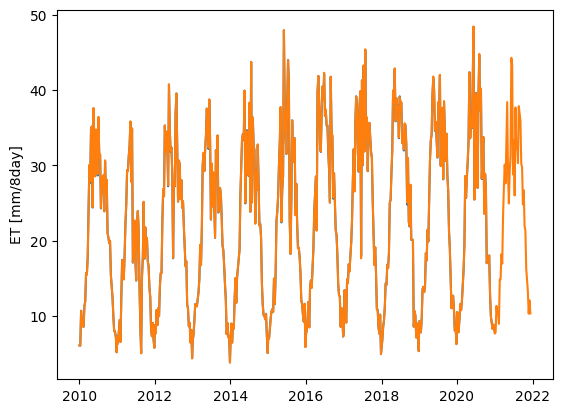

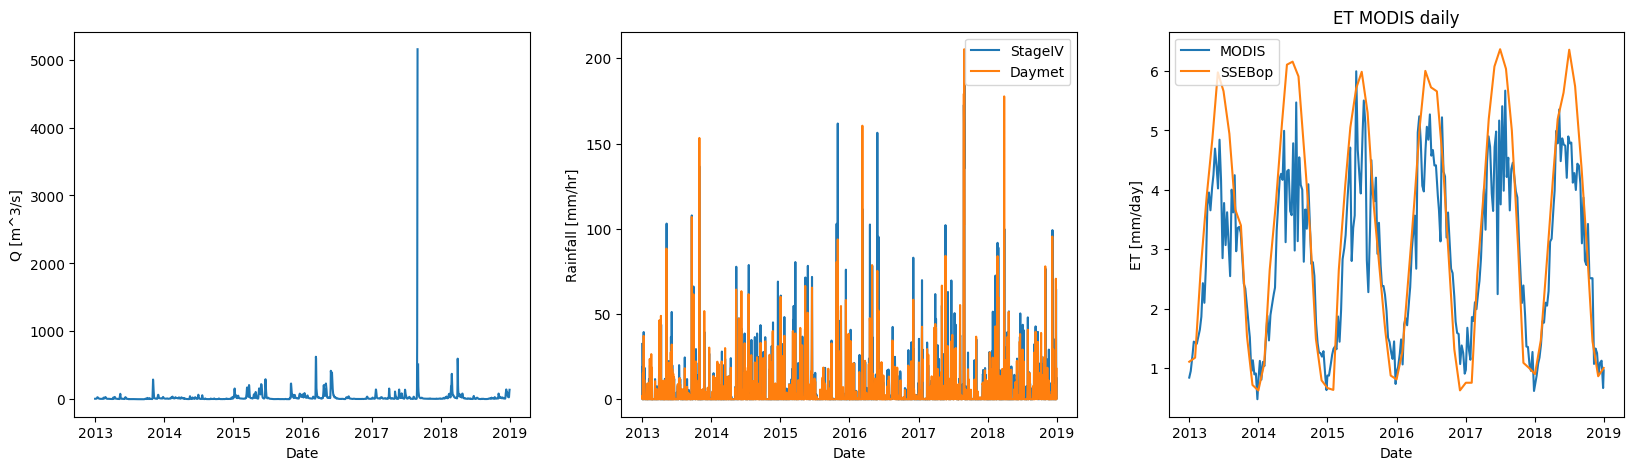

In [11]:
%matplotlib inline
# Set start and end date for making the plot

# start_date = '2016-10-01'
# end_date = '2018-09-30'

# start_date = '2010-01-01'
# end_date = '2019-12-30'

start_date = '2013-01-01'
end_date = '2018-12-30'

fig = plt.figure()
# set size
fig.set_figwidth(20)
fig.set_figheight(5)

# Streamflow
ax = fig.add_subplot(1,3,1)
ax.plot(Q_obs_daily[start_date:end_date]['Q [$m^3/s$]'], label='Obs')
ax.set_xlabel('Date')
ax.set_ylabel('Q [m^3/s]')
# Preci
ax = fig.add_subplot(1,3,2)
ax.plot(Rainfall_StageIV[start_date:end_date]['Rainfall [mm/day]'], label='StageIV')
ax.plot(Rainfall_Daymet[start_date:end_date]['Rainfall [mm/day]'], label='Daymet')
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall [mm/hr]')
ax.legend()
# ET
ax = fig.add_subplot(1,3,3)
ax.plot(ET_MODIS_daily[start_date:end_date]['ET [mm/day]'], label='MODIS')
ax.plot(ET_SSEBop_daily[start_date:end_date]['ET [mm/day]'], label='SSEBop')
ax.set_title('ET MODIS daily')
ax.set_ylabel('ET [mm/day]')
ax.set_xlabel('Date')
ax.legend()
plt.show()

In [12]:
# Get the accumulation of each variable. Let's express the mass balance as surface water balance

P_obs_StageIV_acum = np.nancumsum(Rainfall_StageIV[start_date:end_date]['Rainfall [mm/day]'].values/1000) # [m] over basin area
P_obs_Daymet_acum = np.nancumsum(Rainfall_Daymet[start_date:end_date]['Rainfall [mm/day]'].values/1000) # [m] over basin area
# ET_obs_acum = np.nancumsum(ET_MODIS_daily[start_date:end_date]['ET [mm/day]'].values/1000) # [m] over basin area
ET_obs_acum = np.nancumsum(ET_SSEBop_daily[start_date:end_date]['ET [mm/day]'].values/1000) # [m] over basin area

Q_obs_acum = np.nancumsum(Q_obs_daily[start_date:end_date]['Q [$m^3/s$]'].values*24*60*60/watershed_area) # [m] over basin area

Storage_StageIV_acum = P_obs_StageIV_acum - ET_obs_acum - Q_obs_acum
Storage_Daymet_acum = P_obs_Daymet_acum - ET_obs_acum - Q_obs_acum

<Axes: >

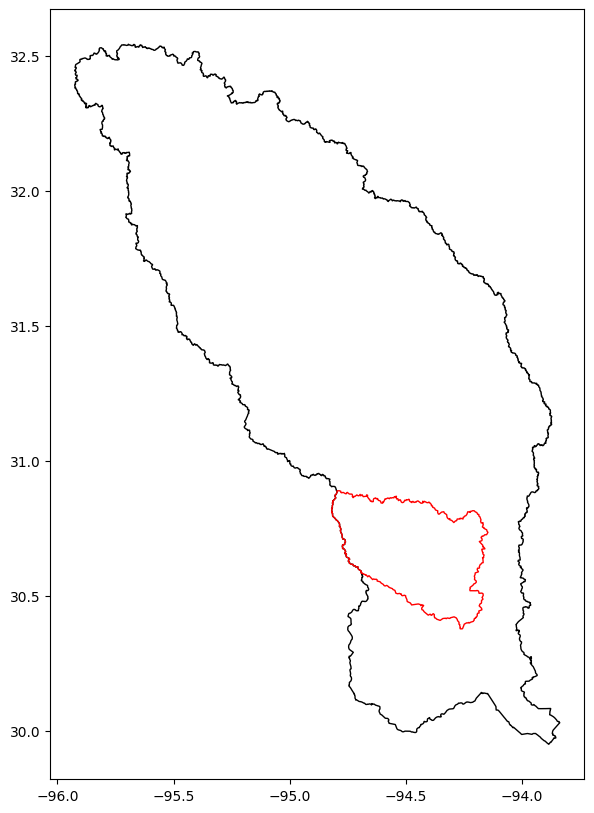

In [13]:
# Plot the watersheds for reference
HUC_04 = gpd.read_file(f'../data-processed/basin/watershed_HUC4_1202.shp')
fig, ax = plt.subplots(figsize=(10, 10))
HUC_04.plot(ax=ax, facecolor="none", edgecolor="black")
watershed_gauge.plot(ax=ax, facecolor="none", edgecolor="red")

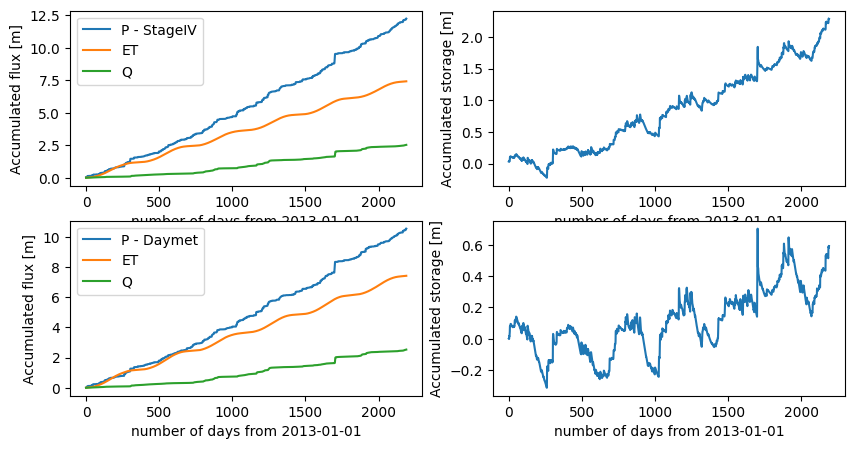

In [14]:
# Plot the surface water balance
fig = plt.figure()
# set size
fig.set_figwidth(10)
fig.set_figheight(5)
ax = fig.add_subplot(2,2,1)
ax.plot(P_obs_StageIV_acum, label='P - StageIV')
ax.plot(ET_obs_acum, label='ET')
ax.plot(Q_obs_acum, label='Q')
ax.set_xlabel(f'number of days from {start_date}')
ax.set_ylabel('Accumulated flux [m]')
ax.legend() 

ax = fig.add_subplot(2,2,2)
ax.plot(Storage_StageIV_acum, label='Storage')
ax.set_xlabel(f'number of days from {start_date}')
ax.set_ylabel('Accumulated storage [m]')

ax = fig.add_subplot(2,2,3)
ax.plot(P_obs_Daymet_acum, label='P - Daymet')
ax.plot(ET_obs_acum, label='ET')
ax.plot(Q_obs_acum, label='Q')
ax.set_xlabel(f'number of days from {start_date}')
ax.set_ylabel('Accumulated flux [m]')
ax.legend() 

ax = fig.add_subplot(2,2,4)
ax.plot(Storage_Daymet_acum, label='Storage')
ax.set_xlabel(f'number of days from {start_date}')
ax.set_ylabel('Accumulated storage [m]')

plt.show()


In [15]:
# Compare monthly ET from different products
ET_MODIS_monthly = ET_MODIS.resample('M').sum()*0.1 # [mm/month]
ET_MODIS_monthly=ET_MODIS_monthly.drop(ET_MODIS_monthly.columns[-1:], axis=1)
ET_MODIS_monthly = ET_MODIS_monthly.rename(columns={'mean':'ET [mm/month]'})

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44350/88377954.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ET_MODIS_monthly = ET_MODIS.resample('M').sum()*0.1 # [mm/month]


In [16]:
# Compare monthly ET from different products
# ET_MODIS_monthly = ET_MODIS_daily.resample('M').sum()
# ET_MODIS_monthly = ET_MODIS_monthly.rename(columns={'ET [mm/day]':'ET [mm/month]'})

# Get the ET_SSEBop_monthly from (https://app.climateengine.org/climateEngine)
# Read cvs file separated by space
# ET_SSEBop_monthly = pd.read_csv('../data-processed/ET_SSEBop/ET_SSebop_08041500_monthly.csv',header=0, sep=' ')
# # Set indextime
# ET_SSEBop_monthly.index = pd.to_datetime(ET_SSEBop_monthly['Date'], format='%Y-%m-%d')
# # Drop the column Date
# ET_SSEBop_monthly = ET_SSEBop_monthly.drop(['Date'], axis=1)
# # change name to mm/month
# ET_SSEBop_monthly = ET_SSEBop_monthly.rename(columns={'ET(mm)':'ET [mm/month]'})

# ET_SSEBop_monthly = ET_SSEBop.resample('M').sum()
# ET_SSEBop_monthly =ET_SSEBop_monthly.drop(ET_SSEBop_monthly.columns[1:], axis=1)


In [17]:



# Load results from OpenET
ET_ensamble = pd.read_csv('../data-processed/ET_openET/ET_ensemble.csv',header=0)

In [18]:
ET_ensamble = ET_ensamble.drop(ET_ensamble.columns[-2:], axis=1)
ET_ensamble = ET_ensamble.rename(columns={' ET':'ET [mm/month]'})
ET_ensamble.index = pd.to_datetime(ET_ensamble.Date, format='%Y-%m-%d')


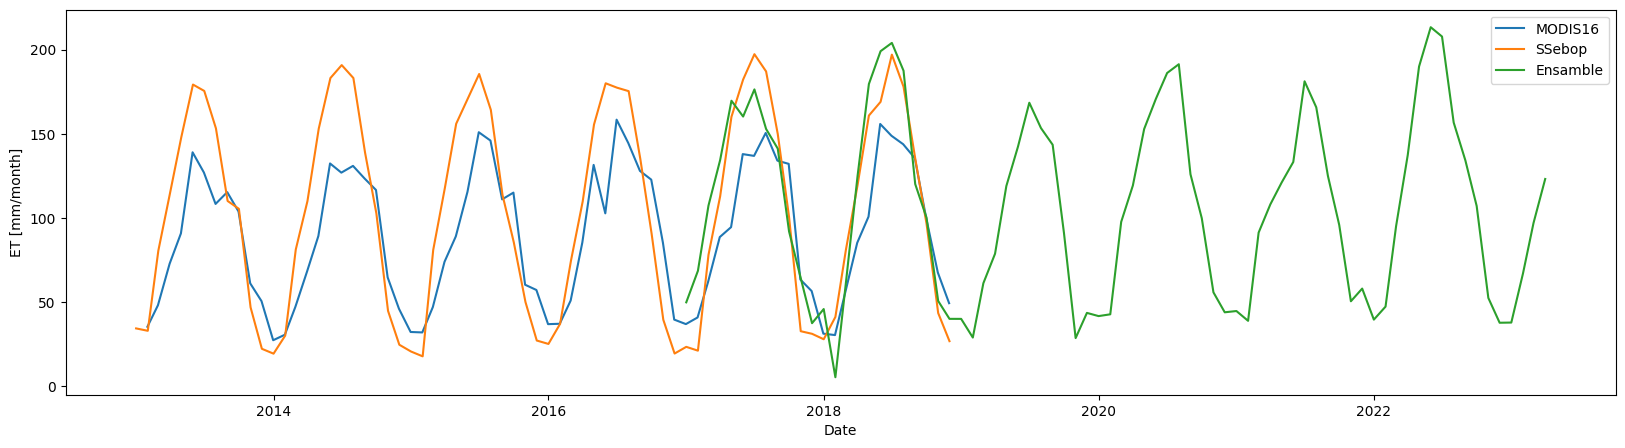

In [19]:
start_date = '2013-01-01'
end_date = '2018-12-30'

fig = plt.figure()
# set size
fig.set_figwidth(20)
fig.set_figheight(5)
# ET
ax = fig.add_subplot(1,1,1)
ax.plot(ET_MODIS_monthly[start_date:end_date]['ET [mm/month]'],label='MODIS16')
ax.plot(ET_SSEBop_monthly[start_date:end_date]['ET [mm/month]'], label = 'SSebop')
ax.plot(ET_ensamble['ET [mm/month]'], label = 'Ensamble')
ax.set_ylabel('ET [mm/month]')
ax.set_xlabel('Date')
ax.legend() 
plt.show()

